In [32]:
# importing lib
import pandas as pd

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
# loading dataset
df = pd.read_excel('Dataset for Data Analytics2.xlsx')

### Data overview

In [35]:
df.dtypes

OrderID                       str
Date               datetime64[us]
CustomerID                    str
Product                       str
Quantity                    int64
UnitPrice                 float64
ShippingAddress               str
PaymentMethod                 str
OrderStatus                   str
TrackingNumber                str
ItemsInCart                 int64
CouponCode                    str
ReferralSource                str
TotalPrice                float64
dtype: object

In [36]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   str           
 1   Date             1200 non-null   datetime64[us]
 2   CustomerID       1200 non-null   str           
 3   Product          1200 non-null   str           
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   str           
 7   PaymentMethod    1200 non-null   str           
 8   OrderStatus      1200 non-null   str           
 9   TrackingNumber   1200 non-null   str           
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       891 non-null    str           
 12  ReferralSource   1200 non-null   str           
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[us](1), float64(2), int64(2), str(9)


### Data cleaning

In [37]:
# checking for duplicates
df.duplicated().sum()

np.int64(0)

In [38]:
df['CustomerID'].duplicated().sum()

np.int64(11)

In [39]:
df['Date']

0      2023-01-04
1      2024-08-23
2      2024-02-27
3      2023-10-15
4      2025-05-08
          ...    
1195   2024-06-20
1196   2024-03-04
1197   2023-07-13
1198   2024-08-22
1199   2023-06-11
Name: Date, Length: 1200, dtype: datetime64[us]

In [40]:
# making a month column name from the date column
df['month'] = df['Date'].dt.month_name()
df['year_month'] = df['Date'].dt.strftime('%Y-%m')

In [41]:
# checking null values
df.isna().sum()

OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
month                0
year_month           0
dtype: int64

In [42]:
# key summary statistics
df.describe()

,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200,1200.000000,1200.000000,1200.000000,1200.000000
mean,2024-03-22 16:58:48,2.945833,356.412750,5.485000,1053.968300
min,2023-01-01 00:00:00,1.000000,11.390000,1.000000,11.390000
25%,2023-08-03 18:00:00,2.000000,186.062500,4.000000,410.520000
50%,2024-03-23 00:00:00,3.000000,364.210000,5.000000,823.615000
75%,2024-11-08 12:00:00,4.000000,521.570000,7.000000,1578.475000
max,2025-06-30 00:00:00,5.000000,699.930000,10.000000,3456.400000
std,NaN,1.407557,197.177146,2.281983,819.856558


In [43]:
# summary statistics of the TotalPrice column
df['TotalPrice'].describe()

count    1200.000000
mean     1053.968300
std       819.856558
min        11.390000
25%       410.520000
50%       823.615000
75%      1578.475000
max      3456.400000
Name: TotalPrice, dtype: float64

### Visual Analysis

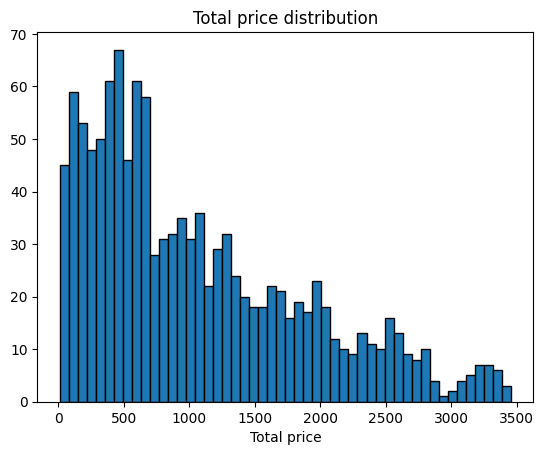

In [44]:
# a histogram of the distribution of the TotalPrice column
fig, ax = plt.subplots()
ax.hist(data=df, x='TotalPrice', bins=50, edgecolor='black')
plt.title('Total price distribution')
plt.xlabel('Total price')
plt.show()

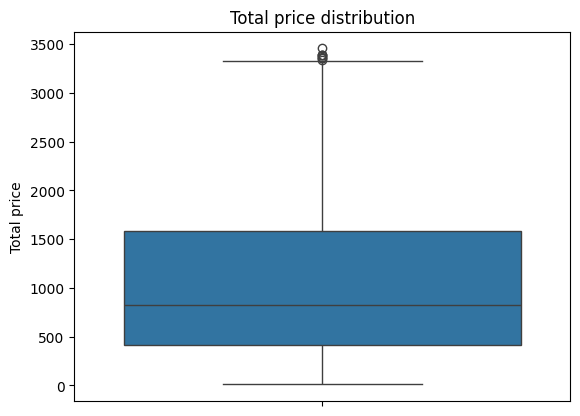

In [45]:
# a boxplot of TotalPrice column
# detecting outliers
sns.boxplot(data=df,y='TotalPrice')
plt.title('Total price distribution')
plt.ylabel('Total price')
plt.show()

In [46]:
# IQR (Q3 - Q1)
1578.475000 - 410.520000

1167.955

In [47]:
lower_bound = 410.520000 - (1.5 * 1167.955)
upper_bound = 1578.475000 + (1.5 * 1167.955)
lower_bound

-1341.4125

In [48]:
upper_bound

3330.4075

In [49]:
outliers = df[(df['TotalPrice'] < lower_bound) | (df['TotalPrice'] > upper_bound)]
outliers

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,month,year_month
107,ORD200107,2023-03-27,C16775,Printer,5,670.75,848 Main St,Gift Card,Shipped,TRK34392124,8,FREESHIP,Instagram,3353.75,March,2023-03
326,ORD200326,2024-07-01,C65986,Laptop,5,670.48,273 Main St,Gift Card,Returned,TRK98353867,5,SAVE10,Facebook,3352.40,July,2024-07
328,ORD200328,2023-02-28,C18404,Tablet,5,674.04,546 Main St,Online,Cancelled,TRK89401624,7,SAVE10,Google,3370.20,February,2023-02
469,ORD200469,2023-11-26,C13877,Chair,5,676.98,893 Main St,Cash,Cancelled,TRK17254691,5,NaN,Facebook,3384.90,November,2023-11
632,ORD200632,2023-05-02,C67260,Laptop,5,678.16,463 Main St,Gift Card,Delivered,TRK38229104,7,WINTER15,Facebook,3390.80,May,2023-05
789,ORD200789,2023-08-17,C57276,Tablet,5,691.28,183 Main St,Online,Delivered,TRK75899752,10,SAVE10,Email,3456.40,August,2023-08
1065,ORD201065,2023-10-30,C47778,Printer,5,666.80,488 Main St,Debit Card,Delivered,TRK79504329,7,SAVE10,Referral,3334.00,October,2023-10
1122,ORD201122,2023-06-07,C38840,Monitor,5,678.19,766 Main St,Online,Returned,TRK32496970,8,NaN,Facebook,3390.95,June,2023-06


In [50]:
# checking TotalPrice values
df['calcTotalPrice'] = (df['Quantity'] * df['UnitPrice'])

In [51]:
# calc the difference between items in cart and number of items paid for 
df['CartDifference'] = (df['ItemsInCart'] - df['Quantity'])

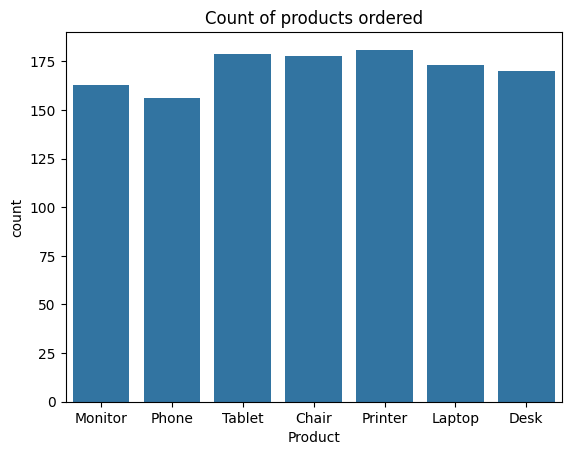

In [52]:
# plotting the count of products
sns.countplot(data=df, x='Product')
plt.title('Count of products ordered')
plt.show()

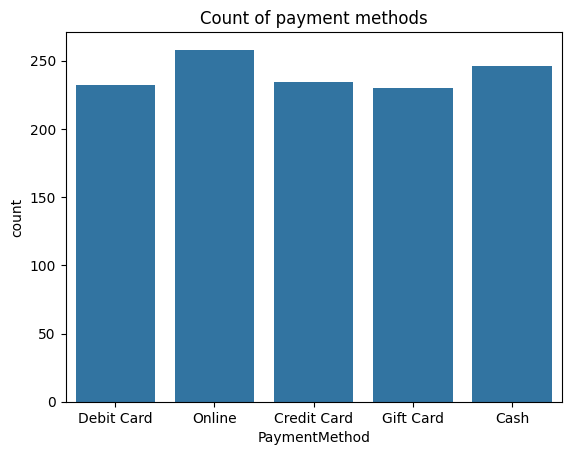

In [53]:
# plotting the count of pyment methods
sns.countplot(data=df, x='PaymentMethod')
plt.title('Count of payment methods')
plt.show()

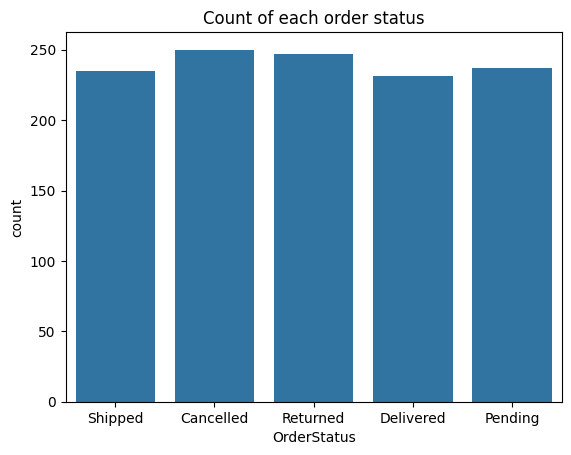

In [54]:
# plotting the count of each order status
sns.countplot(data=df, x='OrderStatus')
plt.title('Count of each order status')
plt.show()

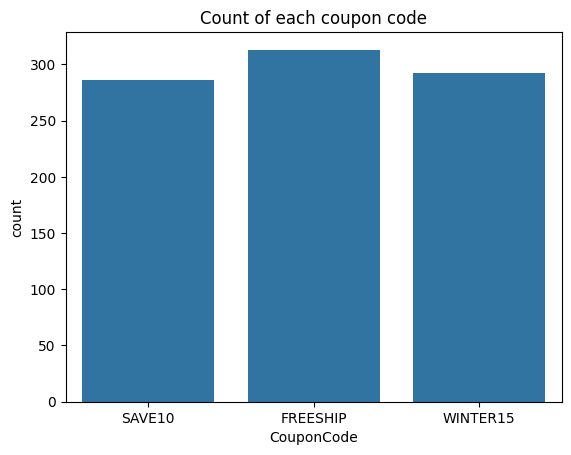

In [55]:
# plotting the count of coupon codes
sns.countplot(data=df, x='CouponCode')
plt.title('Count of each coupon code')
plt.show()

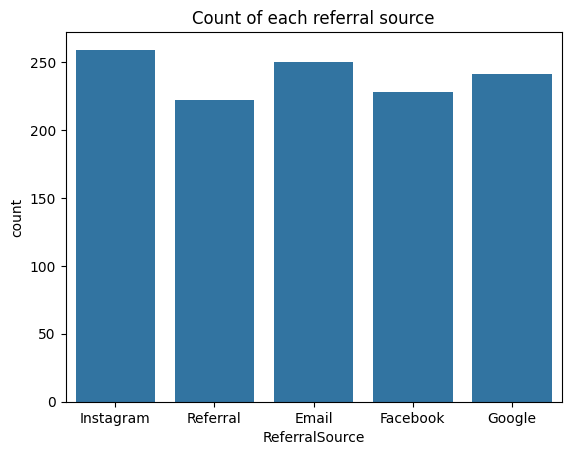

In [56]:
# plotting the count of referral sources
sns.countplot(data=df, x='ReferralSource')
plt.title('Count of each referral source')
plt.show()

In [57]:
# grouping data by month to observe the amount spent by customers over time
priceovertime = df.groupby('year_month')['TotalPrice'].agg(['sum', 'mean','median', 'count'])
priceovertime.index = pd.to_datetime(priceovertime.index)
priceovertime

,sum,mean,median,count
year_month,,,,
2023-01-01,56685.75,1206.079787,1067.620,47
2023-02-01,40117.66,1084.261081,850.060,37
2023-03-01,48609.37,1130.450465,1039.560,43
2023-04-01,27751.71,895.216452,618.680,31
2023-05-01,63836.84,1302.792653,1248.320,49
2023-06-01,49500.19,1100.004222,1010.130,45
2023-07-01,42820.66,973.196818,670.955,44
2023-08-01,54352.14,1065.728235,889.680,51
2023-09-01,29526.67,1018.161034,824.280,29


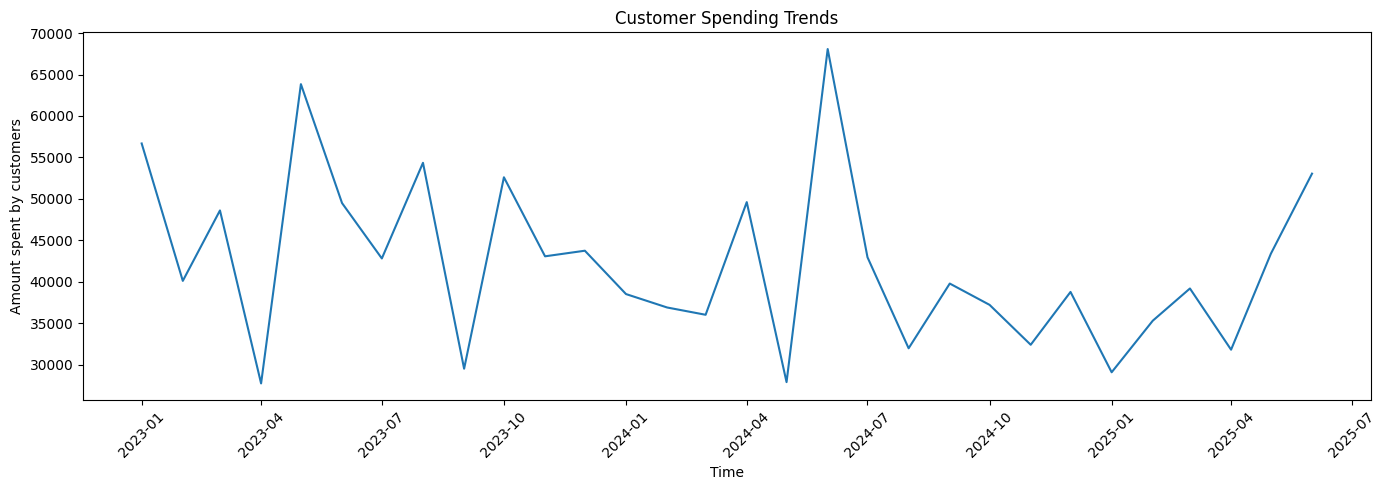

In [58]:
# plotting the amount spent by customers over time
plt.figure(figsize=(14,5))
plt.plot(priceovertime.index, priceovertime['sum'])
plt.title('Customer Spending Trends')
plt.xlabel('Time')
plt.ylabel('Amount spent by customers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [59]:
# grouping by product to observe total quantity and total price from each
product_sales = df.groupby("Product").agg({"Quantity": "sum", "TotalPrice": "sum"}).sort_values('TotalPrice', ascending=False)
product_sales

,Quantity,TotalPrice
Product,,
Chair,562,195620.11
Printer,542,195612.61
Laptop,535,192126.56
Tablet,497,186568.95
Monitor,480,175651.41
Desk,508,167459.93
Phone,411,151722.39


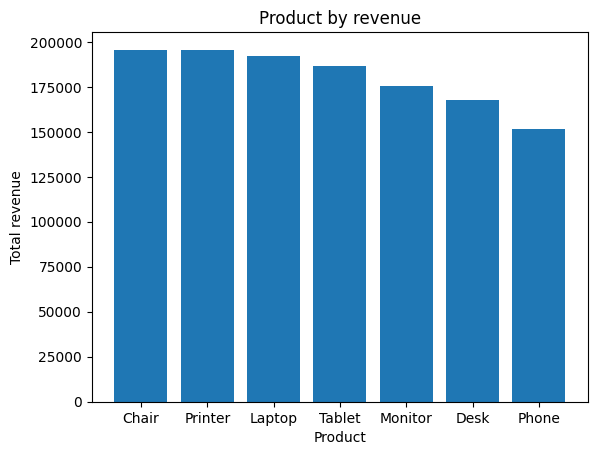

In [60]:
# plotting product by revenue
plt.bar(product_sales.index, product_sales['TotalPrice'])
plt.title('Product by revenue')
plt.xlabel('Product')
plt.ylabel('Total revenue')
plt.show()